In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/processed_data.csv")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(df['is_fraud'].value_counts())

Loaded: 1,852,394 rows x 14 cols
is_fraud
0    1842743
1       9651
Name: count, dtype: int64


In [2]:
features = ['amt','hour','dayofweek','month','is_night',
            'is_high_risk_merchant','is_high_amount',
            'velocity_flag','risk_score']

X = df[features]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Fraud in test: {y_test.sum():,} ({y_test.mean()*100:.3f}%)")

Train: 1,481,915 | Test: 370,479
Fraud in test: 1,930 (0.521%)


In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.85      0.92    368549
           1       0.03      0.83      0.06      1930

    accuracy                           0.85    370479
   macro avg       0.51      0.84      0.49    370479
weighted avg       0.99      0.85      0.92    370479

ROC-AUC: 0.9342


In [4]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)])

lgb_preds = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)[:,1]

print("=== LightGBM ===")
print(classification_report(y_test, lgb_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, lgb_proba):.4f}")

=== LightGBM ===
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    368549
           1       0.10      0.92      0.18      1930

    accuracy                           0.96    370479
   macro avg       0.55      0.94      0.58    370479
weighted avg       0.99      0.96      0.97    370479

ROC-AUC: 0.9849


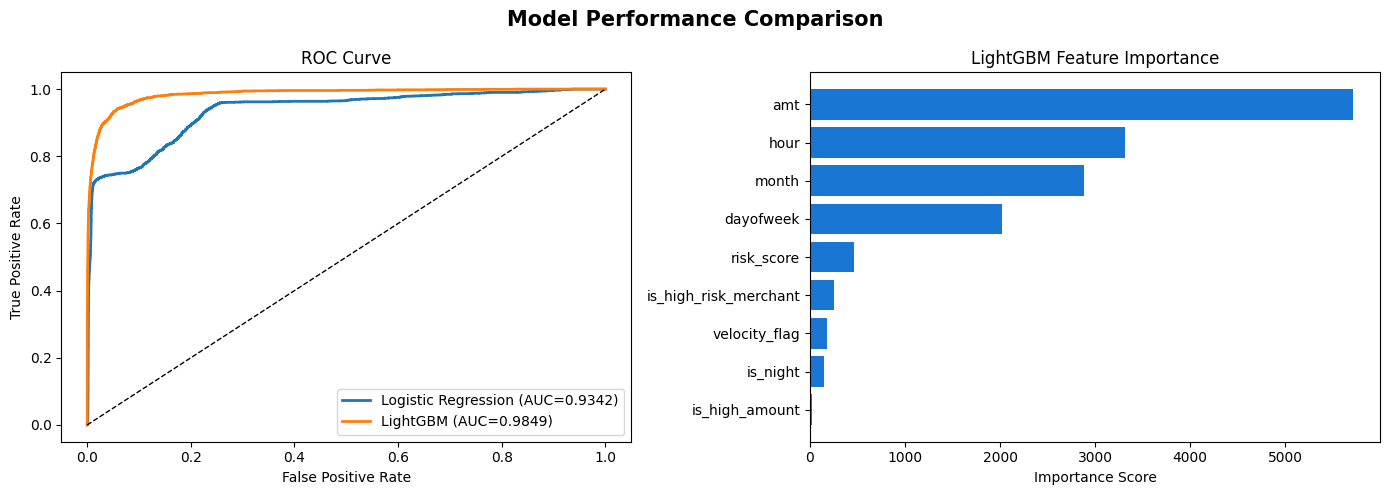

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

# ROC curves
for name, proba in [("Logistic Regression", lr_proba), ("LightGBM", lgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})", linewidth=2)

axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Feature importance — LightGBM
importance = pd.DataFrame({
    'feature': features,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(importance['feature'], importance['importance'], color='#1976d2')
axes[1].set_title('LightGBM Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../reports/03_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

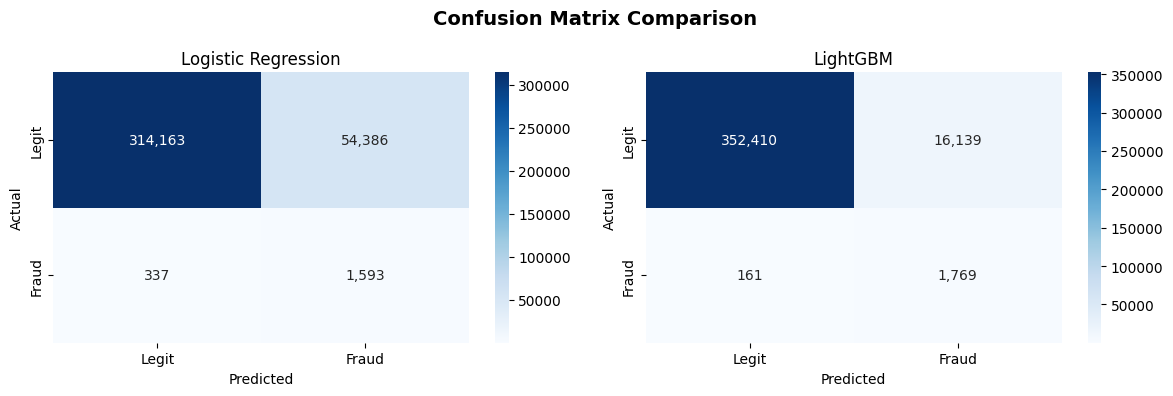

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')

for ax, preds, name in zip(axes,
                            [lr_preds, lgb_preds],
                            ["Logistic Regression", "LightGBM"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import pickle

# Save model and scaler
with open("../models/lgbm_model.pkl", "wb") as f:
    pickle.dump(lgb_model, f)

with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save risk scores to csv
df_test = X_test.copy()
df_test['actual_fraud']  = y_test.values
df_test['lr_risk_score'] = (lr_proba * 100).round(2)
df_test['lgb_risk_score'] = (lgb_proba * 100).round(2)
df_test['lgb_predicted'] = lgb_preds

df_test.to_csv("../data/risk_scores.csv", index=False)

print(f"Models saved to models/")
print(f"Risk scores saved — {df_test.shape[0]:,} rows")
print(f"\nSample risk scores:")
print(df_test[['amt','lgb_risk_score','actual_fraud']].head(10))

Models saved to models/
Risk scores saved — 370,479 rows

Sample risk scores:
            amt  lgb_risk_score  actual_fraud
649993   226.92           30.45             0
1122524    5.28            0.10             0
1775060  420.06           65.80             0
805885     4.07            0.00             0
1176263    8.74            0.06             0
1001845    1.92            0.06             0
846964    70.04            0.04             0
1057624   48.09            0.19             0
792384     7.34            0.01             0
257846     2.62            0.03             0
